# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Imam Dza Qhoir
- **Email:** qhosans@gmail.com
- **ID Dicoding:** shin_zeleo

## Menentukan Pertanyaan Bisnis

- Apakah ada musim tertentu yang membuat penyewaan sepeda lebih ramai dari biasanya?
- Sejauh mana kondisi cuaca memengaruhi jumlah penyewa sepeda harian?
- Pada jam berapa saja penyewaan sepeda biasanya mencapai puncaknya?

## Import Semua Packages/Library yang Digunakan

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [13]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [15]:
day_df.shape

(731, 16)

In [16]:
hour_df.shape

(17379, 17)

**Insight:**
- Dataset ini terbagi menjadi dua, yaitu data harian dan per jam, sehingga memberikan perspektif waktu yang lebih komprehensif terkait penggunaan sepeda.
- Data di dalamnya mencakup berbagai faktor penentu seperti musim, cuaca, suhu, dan total penyewaan, yang sangat mendukung untuk proses analisis pola penggunaan.
- Kombinasi variabel waktu dan kondisi lingkungan menjadikan dataset ini sangat memadai untuk mendalami faktor-faktor apa saja yang memengaruhi tingkat penyewaan.

### Assessing Data

In [17]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [18]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [19]:
print("Jumlah missing value:")
print(day_df.isnull().sum())

print("\nJumlah data duplikat:")
print(day_df.duplicated().sum())

Jumlah missing value:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah data duplikat:
0


**Insight:**
- Tidak ditemukan missing value maupun data duplikat pada dataset, sehingga data dapat langsung digunakan untuk analisis tanpa proses pembersihan yang kompleks.
- Dataset harian memiliki 731 entri, sedangkan dataset per jam memiliki 17.379 entri, yang menunjukkan perbedaan granularitas waktu yang cukup signifikan.
- Beberapa variabel seperti season, weekday, dan weathersit direpresentasikan dalam bentuk angka, namun sebenarnya bersifat kategorikal.
- Rata-rata jumlah penyewaan sepeda per hari berada di kisaran 4.500, dengan nilai maksimum mencapai lebih dari 8.000, yang menunjukkan adanya fluktuasi penggunaan yang cukup tinggi.
- Variabel seperti suhu (temp) dan kelembapan (hum) memiliki rentang nilai yang cukup bervariasi, sehingga berpotensi memengaruhi jumlah penyewaan sepeda.

### Cleaning Data

In [20]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [21]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [22]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

In [23]:
day_df[['season', 'weathersit']].head()

,season,weathersit
0,Spring,Mist
1,Spring,Mist
2,Spring,Clear
3,Spring,Clear
4,Spring,Clear


**Insight:**
- Kolom tanggal (dteday) telah dikonversi ke format datetime sehingga memudahkan analisis berbasis waktu, seperti melihat tren harian maupun bulanan.
- Variabel season dan weathersit yang sebelumnya berupa angka telah diubah menjadi label yang lebih deskriptif, sehingga lebih mudah dipahami saat visualisasi dan interpretasi data.
- Tidak ditemukan missing value maupun data duplikat, sehingga tidak diperlukan proses pembersihan data yang kompleks.
- Secara keseluruhan, dataset sudah dalam kondisi rapi dan siap digunakan untuk tahap eksplorasi lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

In [24]:
day_df.describe()

day_df.groupby('season')['cnt'].describe()
day_df.groupby('weathersit')['cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
weathersit,,,,,,,,
Clear,463.0,4876.786177,1879.483989,431.0,3636.5,4844.0,6458.5,8714.0
Light Snow/Rain,21.0,1803.285714,1240.284449,22.0,705.0,1817.0,2424.0,4639.0
Mist,247.0,4035.862348,1809.109918,605.0,2674.5,4040.0,5257.5,8362.0


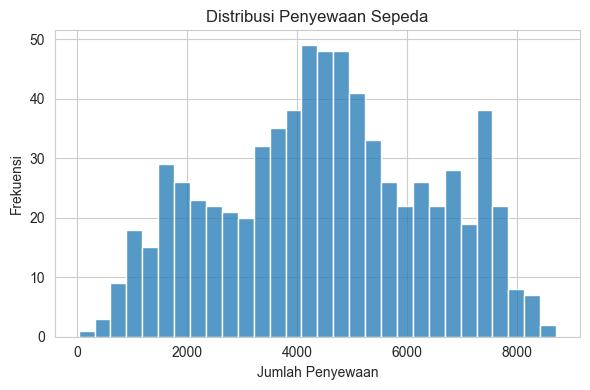

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(day_df['cnt'], bins=30)
plt.title("Distribusi Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi jumlah penyewaan sepeda terlihat cukup bervariasi, dengan mayoritas angkanya terpusat pada kisaran menengah hingga tinggi.
- Faktor cuaca memberikan pengaruh yang sangat jelas, di mana rata-rata penyewaan mencapai puncaknya saat cuaca cerah jika dibandingkan dengan kondisi berkabut atau hujan ringan.
- Sebaliknya, ketika cuaca memburuk seperti saat turun hujan ringan atau salju, angka penyewaan mengalami penurunan yang cukup tajam.
- Berdasarkan visualisasi histogram, sebagian besar hari mencatatkan tingkat penyewaan yang relatif tinggi, walaupun masih dijumpai beberapa hari dengan angka penyewaan yang minim.

## Visualization & Explanatory Analysis

### Pertanyaan 1: 
#### Apakah ada musim tertentu yang membuat penyewaan sepeda lebih ramai dari biasanya?

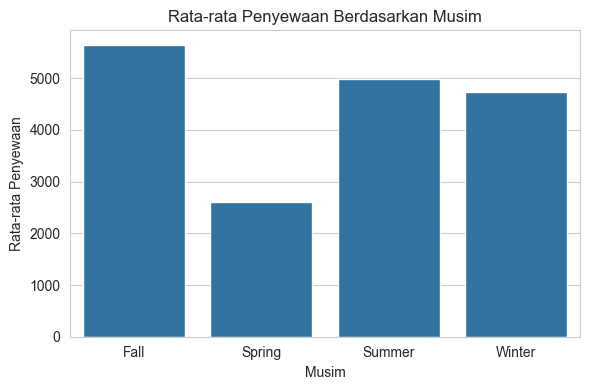

In [26]:
season_df = day_df.groupby('season')['cnt'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='season', y='cnt', data=season_df)
plt.title("Rata-rata Penyewaan Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

**Insight:**
- Musim gugur (Fall) menunjukkan rata-rata penyewaan sepeda tertinggi dibandingkan musim lainnya.
- Musim panas (Summer) dan musim dingin (Winter) juga memiliki tingkat penyewaan yang cukup tinggi, meskipun masih di bawah musim gugur.
- Sebaliknya, musim semi (Spring) memiliki rata-rata penyewaan paling rendah, dengan selisih yang cukup jauh dibandingkan musim lainnya.
- Hal ini menunjukkan bahwa kondisi musim berpengaruh terhadap aktivitas penyewaan sepeda, di mana musim dengan kondisi yang lebih nyaman cenderung meningkatkan jumlah pengguna.

### Pertanyaan 2:
#### Sejauh mana kondisi cuaca memengaruhi jumlah penyewa sepeda harian?

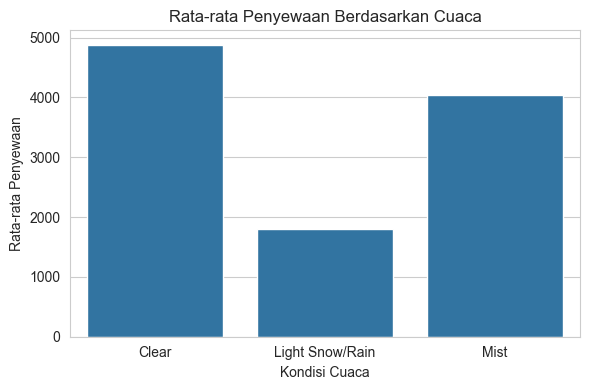

In [27]:
weather_df = day_df.groupby('weathersit')['cnt'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='weathersit', y='cnt', data=weather_df)
plt.title("Rata-rata Penyewaan Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

**Insight:**
- Kondisi cuaca cerah (Clear) menghasilkan rata-rata penyewaan sepeda tertinggi dibandingkan kondisi lainnya.
- Pada kondisi berkabut (Mist), jumlah penyewaan masih tergolong cukup tinggi, meskipun lebih rendah dibandingkan cuaca cerah.
- Sebaliknya, pada kondisi cuaca buruk seperti hujan atau salju ringan (Light Snow/Rain), jumlah penyewaan menurun secara signifikan.
- Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh yang cukup besar terhadap keputusan pengguna dalam menyewa sepeda.

### Pertanyaan 3:
#### Pada jam berapa saja penyewaan sepeda biasanya mencapai puncaknya?

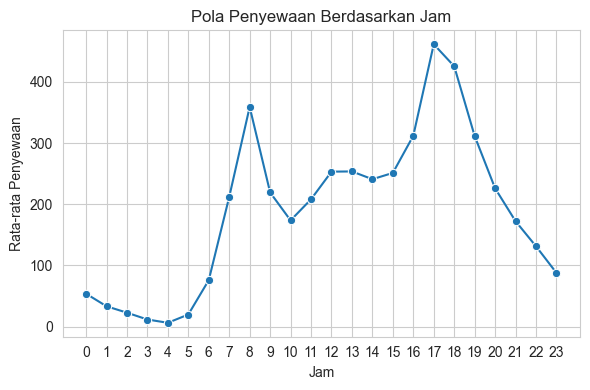

In [28]:
hour_group = hour_df.groupby('hr')['cnt'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.lineplot(x='hr', y='cnt', data=hour_group, marker='o')
plt.title("Pola Penyewaan Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

**Insight:**
- Terdapat dua puncak utama penyewaan sepeda, yaitu pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00–18.00.
- Jumlah penyewaan cenderung sangat rendah pada dini hari hingga subuh, kemudian mulai meningkat signifikan menjelang pagi.
- Setelah puncak pagi, jumlah penyewaan sedikit menurun di siang hari, lalu kembali meningkat hingga mencapai puncak tertinggi di sore hari.
- Pola ini menunjukkan bahwa penggunaan sepeda kemungkinan besar dipengaruhi oleh aktivitas harian seperti berangkat dan pulang kerja.

## Analisis Lanjutan (Opsional)

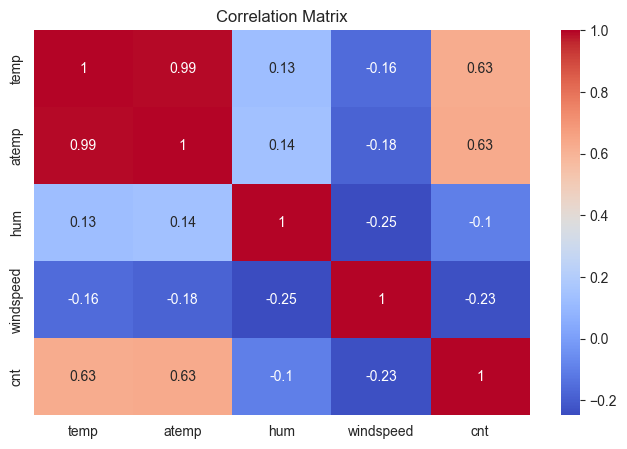

In [29]:
corr = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Insight:**
- Variabel temperatur (temp) dan atemp memiliki korelasi positif yang cukup kuat terhadap jumlah penyewaan (cnt), yang menunjukkan bahwa semakin tinggi suhu, semakin banyak sepeda yang disewa.
- Variabel kelembapan (hum) memiliki korelasi negatif yang lemah terhadap jumlah penyewaan, sehingga tidak terlalu berpengaruh secara signifikan.
- Kecepatan angin (windspeed) juga menunjukkan korelasi negatif terhadap jumlah penyewaan, yang mengindikasikan bahwa kondisi berangin cenderung menurunkan minat pengguna.
- Temperatur (temp) dan atemp memiliki korelasi yang sangat tinggi satu sama lain, sehingga keduanya merepresentasikan informasi yang hampir serupa.

In [30]:
# Clustering berdasarkan jumlah penyewaan
day_df['cnt_group'] = pd.cut(
    day_df['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

day_df['cnt_group'].value_counts().sort_index()

cnt_group
Low       167
Medium    370
High      194
Name: count, dtype: int64

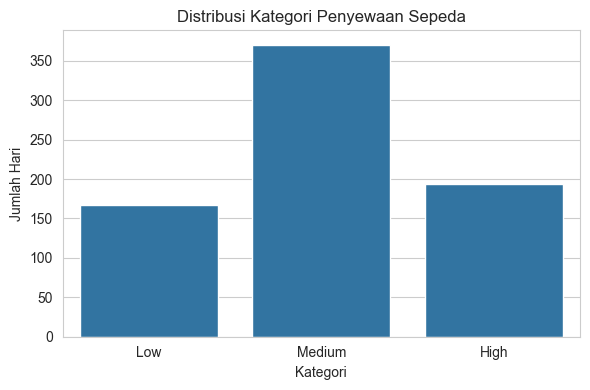

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='cnt_group', data=day_df, order=['Low','Medium','High'])
plt.title("Distribusi Kategori Penyewaan Sepeda")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

**Insight:**
- Data penyewaan sepeda dapat dikelompokkan menjadi tiga kategori: rendah (Low), sedang (Medium), dan tinggi (High).
- Sebagian besar hari berada pada kategori Medium dan High, menunjukkan bahwa permintaan sepeda relatif stabil.
- Kategori High cenderung memiliki suhu yang lebih tinggi dan kondisi cuaca yang lebih mendukung.
- Sebaliknya, kategori Low lebih sering terjadi pada kondisi cuaca kurang ideal.

In [32]:
group_analysis = day_df.groupby(
    'cnt_group',
    observed=True
)[['temp','hum','windspeed']].mean()

group_analysis

,temp,hum,windspeed
cnt_group,,,
Low,0.301225,0.639116,0.220667
Medium,0.518503,0.633224,0.186721
High,0.618431,0.608068,0.171687


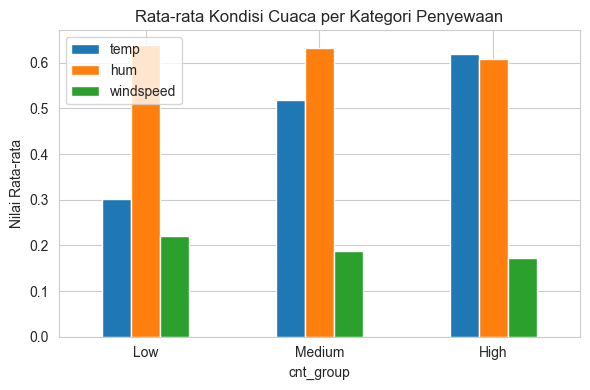

In [33]:
group_analysis.plot(kind='bar', figsize=(6,4))
plt.title("Rata-rata Kondisi Cuaca per Kategori Penyewaan")
plt.ylabel("Nilai Rata-rata")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
- Penyewaan sepeda dapat dikategorikan menjadi tiga tingkat: rendah (Low), sedang (Medium), dan tinggi (High).
- Mayoritas hari berada pada kategori Medium, menunjukkan permintaan yang relatif stabil.
- Kategori High terjadi saat suhu lebih tinggi dan kondisi cuaca lebih mendukung.
- Kecepatan angin yang tinggi cenderung menurunkan jumlah penyewaan sepeda.
- Pola penyewaan berdasarkan jam menunjukkan dua puncak utama pada pagi dan sore hari.

## Conclusion

- Berdasarkan analisis yang dilakukan, musim memiliki pengaruh terhadap jumlah penyewaan sepeda. Musim gugur (Fall) menunjukkan rata-rata penyewaan tertinggi, sedangkan musim semi (Spring) memiliki tingkat penyewaan paling rendah.

- Kondisi cuaca juga berperan penting dalam memengaruhi jumlah penyewaan. Cuaca cerah menghasilkan jumlah penyewaan tertinggi, sementara kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan yang signifikan.

- Pola penyewaan berdasarkan waktu menunjukkan adanya dua puncak utama, yaitu pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00–18.00. Hal ini mengindikasikan bahwa penggunaan sepeda banyak dipengaruhi oleh aktivitas harian seperti berangkat dan pulang kerja.

#### SIMPAN DATA UNTUK DASHBOARD

In [34]:
day_df.to_csv('dashboard/main_data.csv', index=False)

In [35]:
pd.read_csv('dashboard/main_data.csv').head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,cnt_group
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985,Low
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801,Low
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Low
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Low
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Low
